In [1]:
import sys
from pathlib import Path
import random
from collections import deque

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
from snake.snake import Snake

import torch
import torch.nn as nn

import matplotlib.pyplot as plt

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.12.0)


In [2]:
env = Snake(is_cnn=True)
obs = env.reset()

In [3]:
obs.shape

(7, 30, 30)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
print(device)

cuda


In [5]:
class SnakeAgent(nn.Module):
    def __init__(self, n_out):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(7, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, n_out)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.head(x)
    

def choose_action(model, obs, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(0, 4)
    
    obs = torch.tensor(obs, dtype=torch.float32, device=device)
    obs = obs.unsqueeze(0)
    with torch.no_grad():
        out = model(obs)
    return int(torch.argmax(out).item())


def sample_batch(buffer, batch_size):
    batch = random.sample(buffer, batch_size)

    state, action, reward, next_state, done = map(
        np.array, zip(*batch)
    )

    return (
        torch.tensor(state, dtype=torch.float32, device=device),
        torch.tensor(action, dtype=torch.int64, device=device),
        torch.tensor(reward, dtype=torch.float32, device=device),
        torch.tensor(next_state, dtype=torch.float32, device=device),
        torch.tensor(done, dtype=torch.float32, device=device)
    )

def update_target(target, model):
    target.load_state_dict(model.state_dict())

def train_step(model, target, optimizer, batch, gamma=0.99):
    state, action, reward, next_state, done = batch

    with torch.no_grad():
        next_out = target(next_state).max(dim=1)[0]
        target_out = reward + (1 - done) * gamma * next_out

    out = model(state).gather(1, action.unsqueeze(1)).squeeze(1)

    loss = nn.MSELoss()(out, target_out)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def train(env, model, target, optimizer,
          step_per_episode=1000,
          episodes=2000,
          batch_size=64, 
          gamma=0.99,
          target_update_freq=1000):
    
    buffer = deque(maxlen=100_000)
    global_step = 0
    reward_history = []

    for episode in range(episodes):
        obs = env.reset()
        steps = 0
        done = False
        total_reward = 0

        if global_step < 30_000:
            epsilon = 0.7
        elif global_step < 100_000:
            epsilon = 0.5
        elif global_step < 150_000:
            epsilon = 0.4
        elif global_step < 200_000:
            epsilon = 0.3
        elif global_step < 250_000:
            epsilon = 0.2
        elif global_step < 300_000:
            epsilon = 0.1
        else:
            epsilon = 0.05
        
        # epsilon = 0.05
            

        while not done and steps < step_per_episode:
            action = choose_action(model, obs, epsilon)
            next_obs, reward, done = env.update(action)
            
            buffer.append((obs.copy(), action, reward, next_obs.copy(), done))

            obs = next_obs
            total_reward -= 0.1
            total_reward += reward
            global_step += 1
            steps += 1

            if len(buffer) > batch_size:
                batch = sample_batch(buffer, batch_size)
                train_step(model, target, optimizer, batch, gamma)

            if global_step % target_update_freq == 0:
                update_target(target, model)

    
        reward_history.append(total_reward)

        print(f"\rEpisode: {episode + 1} | reward: {total_reward} | eps: {epsilon} | global_steps: {global_step}", end=" ")

    return reward_history

In [6]:
torch.manual_seed(42)

model = SnakeAgent(n_out=4).to(device)

target_network = SnakeAgent(n_out=4).to(device)
target_network.load_state_dict(model.state_dict())

optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)

rewards_history = train(
    env,
    model,
    target_network,
    optimizer,
    step_per_episode=30_000,
    episodes=4000,
    batch_size=64,
    gamma=0.99,
    target_update_freq=2000
)

Episode: 4000 | reward: -12.889999999999956 | eps: 0.05 | global_steps: 452412   

In [7]:
torch.save(model.state_dict(), "snake-agent.pth")
torch.save(target_network.state_dict(), "snake-agent-target.pth")
torch.save(optimizer.state_dict(), "snake-agent-optimizer.pth")

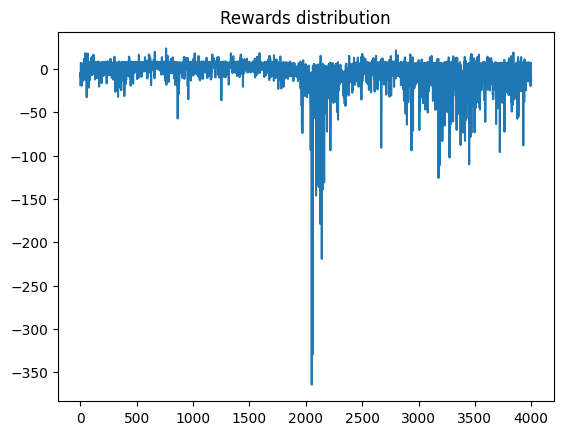

In [8]:
rewards = np.array(rewards_history)

plt.plot(rewards)
plt.title("Rewards distribution")
plt.show()